# Opening Feature Vector Diagnostics

This notebook audits `openings_dataset/opening_feature_vectors.csv` column by column and compares some output defects against the source opening lines in `openings_dataset/all.tsv`.

Main early-castling caveat: `early_castling_tendency` currently measures whether castling is explicitly present inside the opening-line moves. Many source opening lines stop before either side castles, so the column is sparse even though real games castle often.

In [1]:
from pathlib import Path
import csv
import math

import chess
import matplotlib.pyplot as plt
import pandas as pd

from utils.opening_feature_transformer import VECTOR_COLUMNS, normalize_opening_name

FEATURE_PATH = Path('openings_dataset/opening_feature_vectors.csv')
SOURCE_PATH = Path('openings_dataset/all.tsv')

df = pd.read_csv(FEATURE_PATH)
source = pd.read_csv(SOURCE_PATH, sep='\t')

df.shape, source.shape

((3162, 15), (3709, 5))

In [2]:
df.head()

,opening_name,line_count,eco_values,representative_pgn,representative_uci,tactical_density,quiet_position_density,king_safety_risk,early_castling_tendency,opposite_side_castling_tendency,middlegame_complexity,pawn_structure_sharpness,material_imbalance,endgame_likelihood_proxy,structure_diversity
0,Alekhine Defense,4,B02;B03,1. e4 Nf6 2. e5 Nd5 3. d4 d6 4. c4,e2e4 g8f6 e4e5 f6d5 d2d4 d7d6 c2c4,0.223214,0.776786,0.0,0.0,0.0,0.161664,0.05,0.0,0.579082,0.0
1,Alekhine Defense: Balogh Variation,1,B03,1. e4 Nf6 2. e5 Nd5 3. d4 d6 4. Bc4,e2e4 g8f6 e4e5 f6d5 d2d4 d7d6 f1c4,0.250000,0.750000,0.0,0.0,0.0,0.178812,0.05,0.0,0.574639,0.0
2,Alekhine Defense: Brooklyn Variation,1,B02,1. e4 Nf6 2. e5 Ng8,e2e4 g8f6 e4e5 f6g8,0.200000,0.800000,0.0,0.0,0.0,0.152696,0.05,0.0,0.585156,0.0
3,"Alekhine Defense: Brooklyn Variation, Everglad...",1,B02,1. e4 Nf6 2. e5 Ng8 3. d4 f5,e2e4 g8f6 e4e5 f6g8 d2d4 f7f5,0.142857,0.857143,0.0,0.0,0.0,0.166048,0.05,0.0,0.596851,0.0
4,Alekhine Defense: Buckley Attack,1,B02,1. e4 Nf6 2. e5 Nd5 3. Na3,e2e4 g8f6 e4e5 f6d5 b1a3,0.166667,0.833333,0.0,0.0,0.0,0.151980,0.05,0.0,0.592637,0.0


## 1. Global Column Health

This table highlights sparsity, narrow ranges, and low-cardinality behavior. Columns with high zero rate or low unique count are weak for cosine similarity because they contribute little separation.

In [3]:
def column_health(frame, columns):
    rows = []
    for col in columns:
        s = frame[col]
        rows.append({
            'column': col,
            'mean': s.mean(),
            'std': s.std(),
            'min': s.min(),
            'p10': s.quantile(0.10),
            'p25': s.quantile(0.25),
            'p50': s.quantile(0.50),
            'p75': s.quantile(0.75),
            'p90': s.quantile(0.90),
            'max': s.max(),
            'zero_rate': (s == 0).mean(),
            'near_zero_rate_lt_0_05': (s < 0.05).mean(),
            'unique_values': s.nunique(),
        })
    return pd.DataFrame(rows).sort_values(['zero_rate', 'std'], ascending=[False, True])

health = column_health(df, VECTOR_COLUMNS)
health

,column,mean,std,min,p10,p25,p50,p75,p90,max,zero_rate,near_zero_rate_lt_0_05,unique_values
4,opposite_side_castling_tendency,0.004586,0.066094,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.994940,0.994940,5
9,structure_diversity,0.023044,0.138273,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.968691,0.968691,18
7,material_imbalance,0.013308,0.053956,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.665000,0.932638,0.933903,24
3,early_castling_tendency,0.140134,0.292123,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,1.000000,0.784314,0.784314,21
2,king_safety_risk,0.038703,0.063830,0.000000,0.000000,0.000000,0.015000,0.060000,0.090000,0.520000,0.440860,0.719798,98
0,tactical_density,0.297877,0.205636,0.000000,0.000000,0.142857,0.300000,0.444444,0.571429,0.842105,0.171410,0.174573,341
5,middlegame_complexity,0.222698,0.048391,0.131740,0.154881,0.184475,0.225713,0.255446,0.281545,0.423257,0.000000,0.000000,3130
8,endgame_likelihood_proxy,0.530275,0.066544,0.299553,0.443467,0.479465,0.530166,0.588292,0.621123,0.703820,0.000000,0.000000,2888
6,pawn_structure_sharpness,0.212452,0.117688,0.050000,0.050000,0.050000,0.231250,0.300000,0.356250,0.700000,0.000000,0.000000,118
1,quiet_position_density,0.692450,0.209883,0.157895,0.411765,0.543533,0.687500,0.857143,1.000000,1.000000,0.000000,0.000000,350


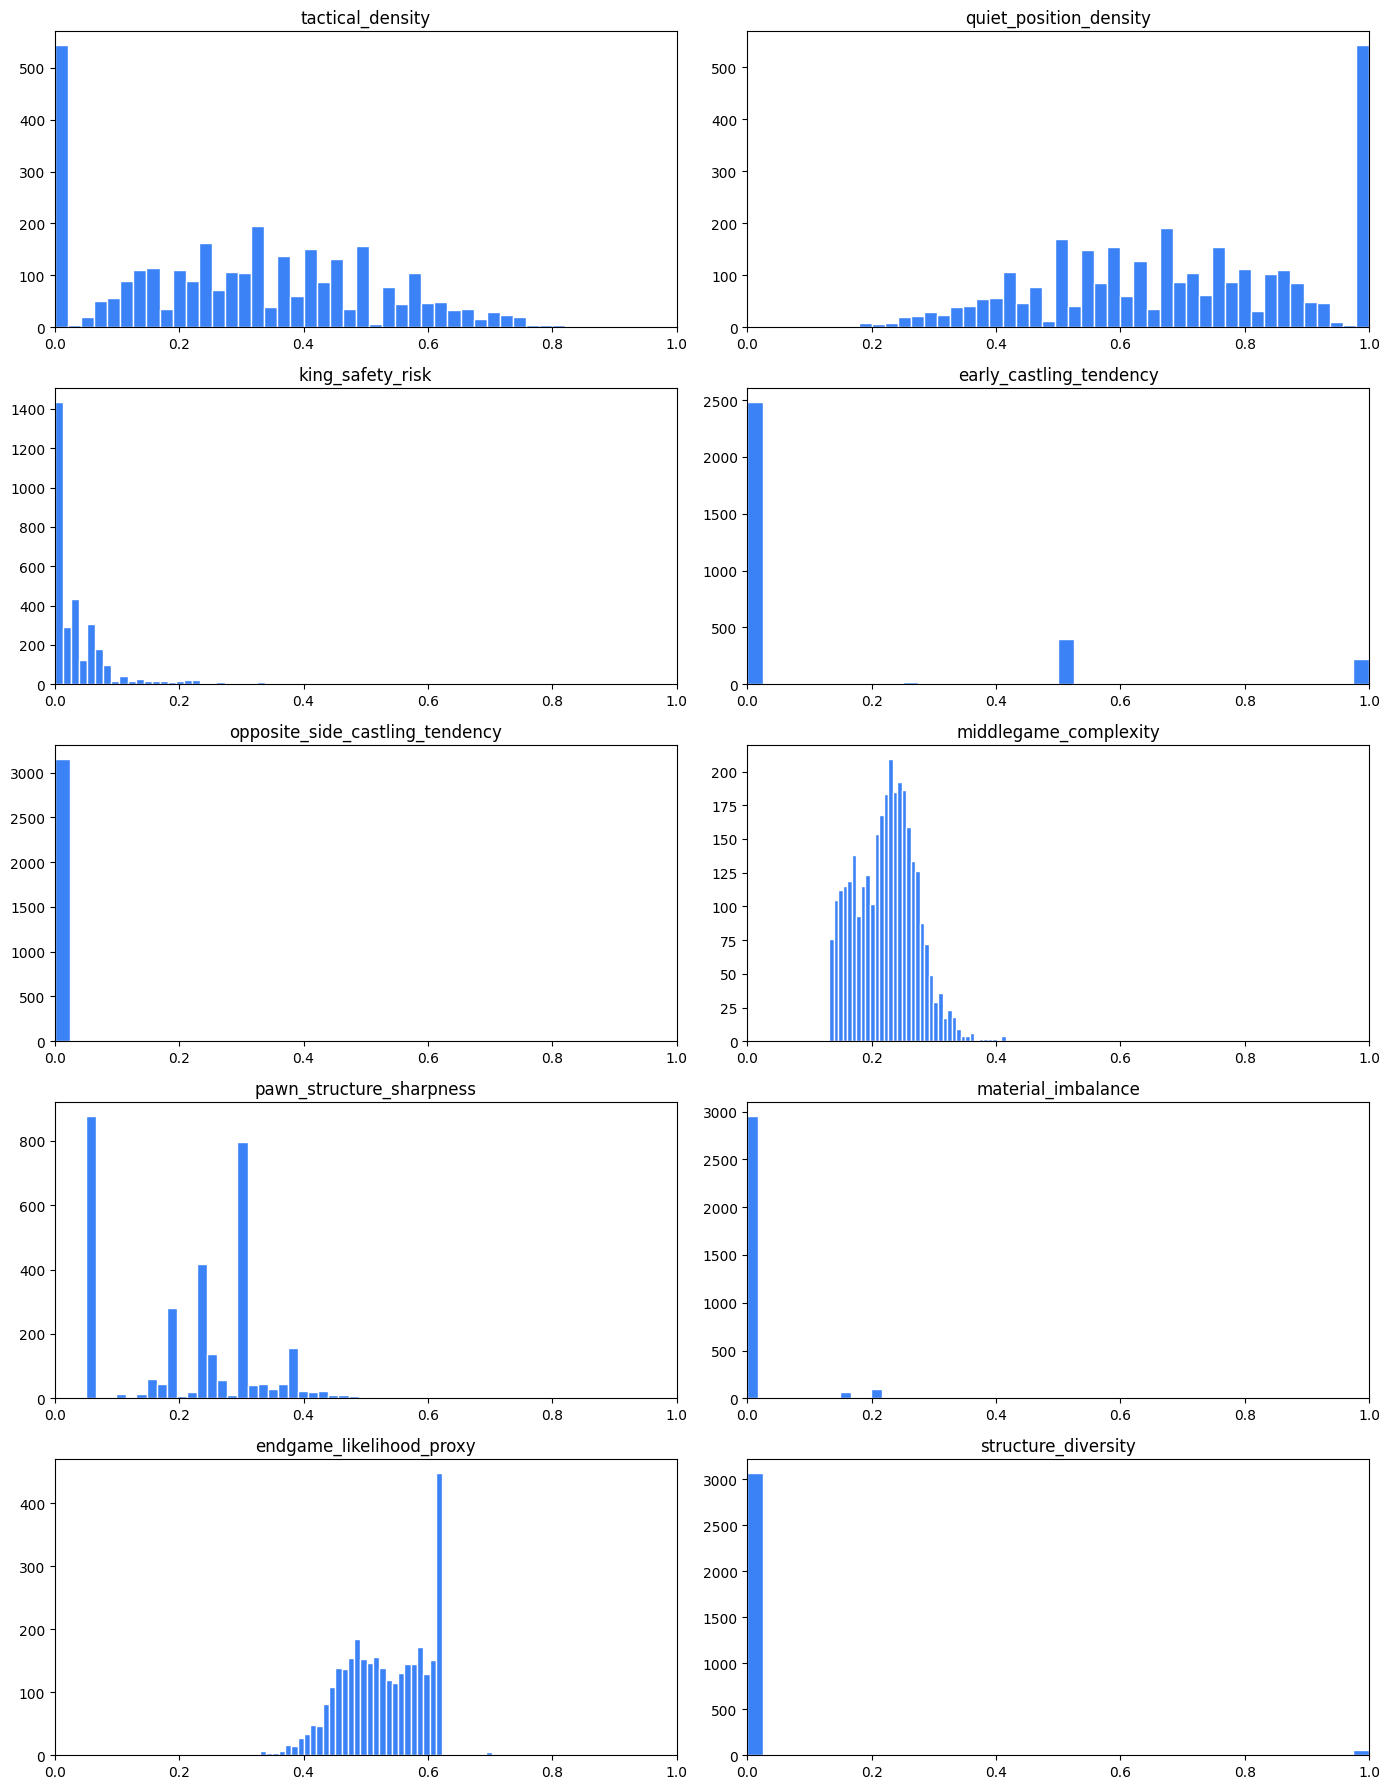

In [4]:
fig, axes = plt.subplots(5, 2, figsize=(14, 18))
for ax, col in zip(axes.ravel(), VECTOR_COLUMNS):
    ax.hist(df[col], bins=40, color='#3b82f6', edgecolor='white')
    ax.set_title(col)
    ax.set_xlim(0, 1)
plt.tight_layout()

## 2. Source-Line Length And Castling Coverage

`early_castling_tendency` is sparse because the implementation only records actual castling moves in the source opening line. The Lichess opening TSV is an opening taxonomy, not a game database, and many rows end around move 2-6 before castling naturally appears.

In [5]:
def castling_info(uci):
    board = chess.Board()
    white_castled = False
    black_castled = False
    white_castle_move = None
    black_castle_move = None
    for move_uci in str(uci).split():
        move = chess.Move.from_uci(move_uci)
        if move not in board.legal_moves:
            break
        color = board.turn
        if board.is_castling(move):
            if color == chess.WHITE:
                white_castled = True
                white_castle_move = board.fullmove_number
            else:
                black_castled = True
                black_castle_move = board.fullmove_number
        board.push(move)
    return pd.Series({
        'source_ply_count': len(str(uci).split()),
        'source_fullmove_count': math.ceil(len(str(uci).split()) / 2),
        'source_white_castled': white_castled,
        'source_black_castled': black_castled,
        'source_any_castled': white_castled or black_castled,
        'source_both_castled': white_castled and black_castled,
        'source_white_castle_move': white_castle_move,
        'source_black_castle_move': black_castle_move,
    })

source_diag = source.copy()
source_diag['group_key'] = source_diag['name'].map(normalize_opening_name)
source_diag = pd.concat([source_diag, source_diag['uci'].apply(castling_info)], axis=1)

source_summary = source_diag.groupby('group_key').agg(
    source_line_count=('uci', 'size'),
    avg_source_ply_count=('source_ply_count', 'mean'),
    max_source_ply_count=('source_ply_count', 'max'),
    any_castle_line_rate=('source_any_castled', 'mean'),
    both_castle_line_rate=('source_both_castled', 'mean'),
    white_castle_line_rate=('source_white_castled', 'mean'),
    black_castle_line_rate=('source_black_castled', 'mean'),
).reset_index()

df_diag = df.copy()
df_diag['group_key'] = df_diag['opening_name'].map(normalize_opening_name)
df_diag = df_diag.merge(source_summary, on='group_key', how='left')

df_diag[['opening_name', 'line_count', 'early_castling_tendency', 'source_line_count', 'avg_source_ply_count', 'max_source_ply_count', 'any_castle_line_rate', 'both_castle_line_rate']].head(20)

,opening_name,line_count,early_castling_tendency,source_line_count,avg_source_ply_count,max_source_ply_count,any_castle_line_rate,both_castle_line_rate
0,Alekhine Defense,4,0.0,4,5.0,7,0.0,0.0
1,Alekhine Defense: Balogh Variation,1,0.0,1,7.0,7,0.0,0.0
2,Alekhine Defense: Brooklyn Variation,1,0.0,1,4.0,4,0.0,0.0
3,"Alekhine Defense: Brooklyn Variation, Everglad...",1,0.0,1,6.0,6,0.0,0.0
4,Alekhine Defense: Buckley Attack,1,0.0,1,5.0,5,0.0,0.0
5,Alekhine Defense: Exchange Variation,1,0.0,1,9.0,9,0.0,0.0
6,"Alekhine Defense: Exchange Variation, Karpov V...",1,1.0,1,21.0,21,1.0,1.0
7,"Alekhine Defense: Exchange Variation, Voronezh...",1,0.5,1,17.0,17,1.0,0.0
8,Alekhine Defense: Four Pawns Attack,1,0.0,1,9.0,9,0.0,0.0
9,"Alekhine Defense: Four Pawns Attack, Cambridge...",1,0.0,1,10.0,10,0.0,0.0


In [6]:
castling_audit = {
    'opening_groups': len(df_diag),
    'groups_with_zero_early_castling': int((df_diag['early_castling_tendency'] == 0).sum()),
    'zero_early_castling_rate': float((df_diag['early_castling_tendency'] == 0).mean()),
    'source_lines_with_any_castle_rate': float(source_diag['source_any_castled'].mean()),
    'source_lines_with_both_castled_rate': float(source_diag['source_both_castled'].mean()),
    'source_lines_ending_before_move_8_rate': float((source_diag['source_fullmove_count'] < 8).mean()),
    'source_lines_ending_before_move_10_rate': float((source_diag['source_fullmove_count'] < 10).mean()),
}
castling_audit

{'opening_groups': 3162,
 'groups_with_zero_early_castling': 2480,
 'zero_early_castling_rate': 0.7843137254901961,
 'source_lines_with_any_castle_rate': 0.2267457535723915,
 'source_lines_with_both_castled_rate': 0.08735508223240766,
 'source_lines_ending_before_move_8_rate': 0.8438932326772715,
 'source_lines_ending_before_move_10_rate': 0.9428417363170666}

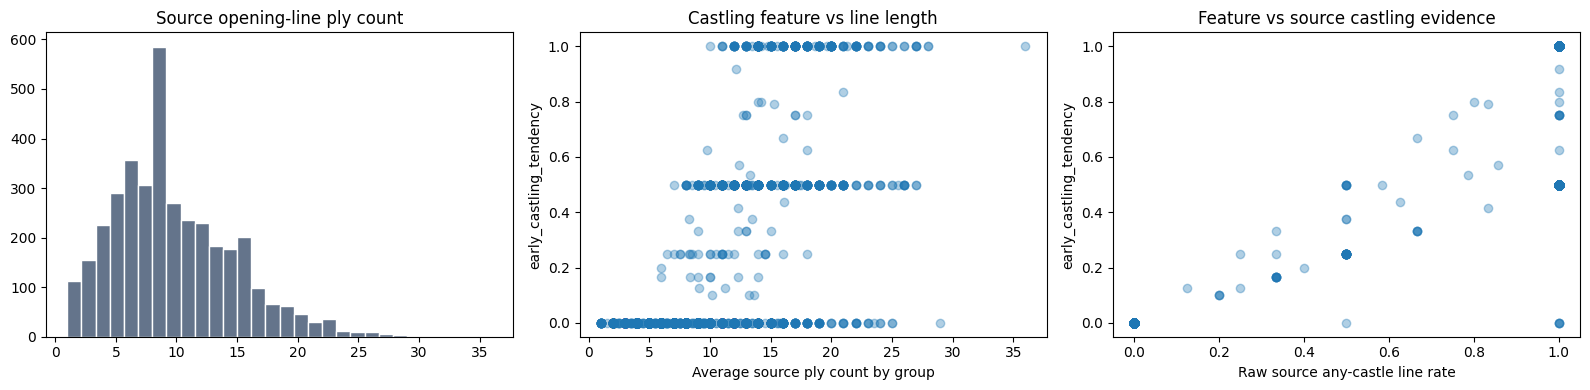

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(source_diag['source_ply_count'], bins=30, color='#64748b', edgecolor='white')
axes[0].set_title('Source opening-line ply count')
axes[1].scatter(df_diag['avg_source_ply_count'], df_diag['early_castling_tendency'], alpha=0.35)
axes[1].set_xlabel('Average source ply count by group')
axes[1].set_ylabel('early_castling_tendency')
axes[1].set_title('Castling feature vs line length')
axes[2].scatter(df_diag['any_castle_line_rate'], df_diag['early_castling_tendency'], alpha=0.35)
axes[2].set_xlabel('Raw source any-castle line rate')
axes[2].set_ylabel('early_castling_tendency')
axes[2].set_title('Feature vs source castling evidence')
plt.tight_layout()

## 3. Per-Column Defect Notes

These are formula-level diagnostics, not claims about chess truth. The goal is to identify whether the column has enough variance and whether it measures realized properties of short opening lines or the intended tendency of real games.

In [8]:
def defect_note(row):
    col = row['column']
    zero_rate = row['zero_rate']
    std = row['std']
    notes = []
    if zero_rate > 0.75:
        notes.append('very sparse')
    elif zero_rate > 0.40:
        notes.append('moderately sparse')
    if std < 0.04:
        notes.append('low variance')
    if row['p75'] == 0:
        notes.append('75th percentile is zero')
    if col == 'early_castling_tendency':
        notes.append('measures explicit castling in short source lines, not real-game castling frequency')
    if col == 'opposite_side_castling_tendency':
        notes.append('requires both sides to castle inside the source line, so it is expected to be extremely sparse')
    if col == 'material_imbalance':
        notes.append('measures realized material imbalance in final opening position; most openings remain materially equal')
    if col == 'structure_diversity':
        notes.append('group-level entropy; exact-name groups often have one line, forcing zero diversity')
    if col == 'king_safety_risk':
        notes.append('final-position risk is weak when lines end early and kings are still normal/untouched')
    return '; '.join(notes) or 'distribution looks usable, inspect calibration against GT vectors'

diagnosis = health.copy()
diagnosis['diagnosis'] = diagnosis.apply(defect_note, axis=1)
diagnosis[['column', 'mean', 'std', 'zero_rate', 'p50', 'p75', 'max', 'diagnosis']]

,column,mean,std,zero_rate,p50,p75,max,diagnosis
4,opposite_side_castling_tendency,0.004586,0.066094,0.994940,0.000000,0.000000,1.000000,very sparse; 75th percentile is zero; requires...
9,structure_diversity,0.023044,0.138273,0.968691,0.000000,0.000000,1.000000,very sparse; 75th percentile is zero; group-le...
7,material_imbalance,0.013308,0.053956,0.932638,0.000000,0.000000,0.665000,very sparse; 75th percentile is zero; measures...
3,early_castling_tendency,0.140134,0.292123,0.784314,0.000000,0.000000,1.000000,very sparse; 75th percentile is zero; measures...
2,king_safety_risk,0.038703,0.063830,0.440860,0.015000,0.060000,0.520000,moderately sparse; final-position risk is weak...
0,tactical_density,0.297877,0.205636,0.171410,0.300000,0.444444,0.842105,"distribution looks usable, inspect calibration..."
5,middlegame_complexity,0.222698,0.048391,0.000000,0.225713,0.255446,0.423257,"distribution looks usable, inspect calibration..."
8,endgame_likelihood_proxy,0.530275,0.066544,0.000000,0.530166,0.588292,0.703820,"distribution looks usable, inspect calibration..."
6,pawn_structure_sharpness,0.212452,0.117688,0.000000,0.231250,0.300000,0.700000,"distribution looks usable, inspect calibration..."
1,quiet_position_density,0.692450,0.209883,0.000000,0.687500,0.857143,1.000000,"distribution looks usable, inspect calibration..."


## 4. Correlation And Redundancy

High positive or negative correlations indicate redundant features or formulas that are mechanically coupled. For example, `tactical_density` and `quiet_position_density` are expected to be strongly inverse, but they should not become perfect complements if both are intended to coexist.

In [9]:
corr = df[VECTOR_COLUMNS].corr()
corr

,tactical_density,quiet_position_density,king_safety_risk,early_castling_tendency,opposite_side_castling_tendency,middlegame_complexity,pawn_structure_sharpness,material_imbalance,endgame_likelihood_proxy,structure_diversity
tactical_density,1.000000,-0.989557,0.444277,0.023120,0.044461,0.620289,0.473169,0.226031,-0.864845,0.033420
quiet_position_density,-0.989557,1.000000,-0.460322,-0.060409,-0.048303,-0.657990,-0.493176,-0.229784,0.865031,-0.037290
king_safety_risk,0.444277,-0.460322,1.000000,-0.050854,-0.002995,0.513997,0.356409,0.294389,-0.644917,-0.001565
early_castling_tendency,0.023120,-0.060409,-0.050854,1.000000,0.171008,0.312969,0.161521,0.090055,-0.005040,0.003724
opposite_side_castling_tendency,0.044461,-0.048303,-0.002995,0.171008,1.000000,0.081184,0.018298,0.014375,-0.038781,0.003292
middlegame_complexity,0.620289,-0.657990,0.513997,0.312969,0.081184,1.000000,0.741845,0.380046,-0.683806,0.033278
pawn_structure_sharpness,0.473169,-0.493176,0.356409,0.161521,0.018298,0.741845,1.000000,0.238172,-0.560582,0.056400
material_imbalance,0.226031,-0.229784,0.294389,0.090055,0.014375,0.380046,0.238172,1.000000,-0.183033,0.007644
endgame_likelihood_proxy,-0.864845,0.865031,-0.644917,-0.005040,-0.038781,-0.683806,-0.560582,-0.183033,1.000000,-0.029264
structure_diversity,0.033420,-0.037290,-0.001565,0.003724,0.003292,0.033278,0.056400,0.007644,-0.029264,1.000000


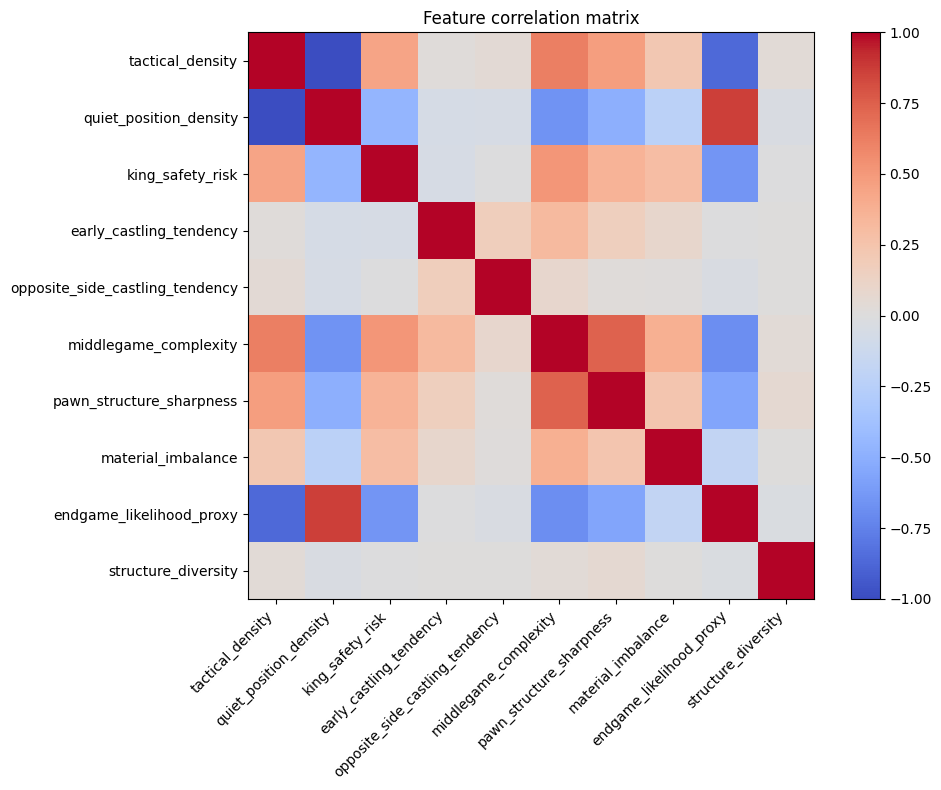

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(len(VECTOR_COLUMNS)))
ax.set_yticks(range(len(VECTOR_COLUMNS)))
ax.set_xticklabels(VECTOR_COLUMNS, rotation=45, ha='right')
ax.set_yticklabels(VECTOR_COLUMNS)
fig.colorbar(im, ax=ax)
ax.set_title('Feature correlation matrix')
plt.tight_layout()

## 5. Top And Bottom Examples Per Column

Manual spot-checking the extremes is useful because a feature can have a statistically reasonable distribution but still rank openings incorrectly.

In [11]:
def extremes(frame, col, n=8):
    fields = ['opening_name', 'line_count', col, 'representative_pgn']
    return pd.concat([
        frame[fields].sort_values(col, ascending=False).head(n).assign(bucket='highest'),
        frame[fields].sort_values(col, ascending=True).head(n).assign(bucket='lowest'),
    ])

extremes(df, 'early_castling_tendency')

,opening_name,line_count,early_castling_tendency,representative_pgn,bucket
1581,"Neo-Grünfeld Defense: Classical Variation, Mod...",1,1.0,1. d4 Nf6 2. Nf3 g6 3. g3 Bg7 4. Bg2 O-O 5. O-...,highest
2113,"Queen's Indian Defense: Classical Variation, T...",1,1.0,1. d4 Nf6 2. c4 e6 3. Nf3 b6 4. g3 Bb7 5. Bg2 ...,highest
2847,"Sicilian Defense: Scheveningen Variation, Clas...",1,1.0,1. e4 c5 2. Nf3 e6 3. d4 cxd4 4. Nxd4 Nc6 5. N...,highest
1054,"Italian Game: Evans Gambit, Richardson Attack",1,1.0,1. e4 e5 2. Nf3 Nc6 3. Bc4 Bc5 4. b4 Bxb4 5. c...,highest
2273,"Ruy Lopez: Classical Variation, Modern Main Line",1,1.0,1. e4 e5 2. Nf3 Nc6 3. Bb5 Nf6 4. O-O Bc5 5. c...,highest
2265,"Ruy Lopez: Classical Defense, Benelux Variation",1,1.0,1. e4 e5 2. Nf3 Nc6 3. Bb5 Nf6 4. O-O Bc5 5. c...,highest
2890,"Sicilian Defense: Sozin Attack, Main Line, She...",1,1.0,1. e4 c5 2. Nf3 d6 3. d4 cxd4 4. Nxd4 Nf6 5. N...,highest
2251,"Ruy Lopez: Berlin Defense, Tarrasch Trap",1,1.0,1. e4 e5 2. Nf3 Nc6 3. Bb5 d6 4. d4 Bd7 5. Nc3...,highest
0,Alekhine Defense,4,0.0,1. e4 Nf6 2. e5 Nd5 3. d4 d6 4. c4,lowest
1965,Queen's Gambit Declined: Alapin Variation,1,0.0,1. d4 e6 2. c4 b6 3. Nc3 d5,lowest


In [12]:
for col in VECTOR_COLUMNS:
    print('\n' + '=' * 100)
    print(col)
    display(extremes(df, col, n=5))


tactical_density


,opening_name,line_count,tactical_density,representative_pgn,bucket
2556,"Semi-Slav Defense: Marshall Gambit, Tolush Var...",1,0.842105,1. d4 d5 2. c4 e6 3. Nc3 c6 4. e4 dxe4 5. Nxe4...,highest
2502,Scotch Game: Gottschall Variation,1,0.840000,1. e4 e5 2. Nf3 Nc6 3. d4 exd4 4. Nxd4 Bc5 5. ...,highest
2478,"Scandinavian Defense: Portuguese Gambit, Jadou...",1,0.833333,1. e4 d5 2. exd5 Nf6 3. d4 Bg4 4. f3 Bf5 5. Bb...,highest
2077,Queen's Gambit Declined: Semi-Tarrasch Defense...,1,0.812500,1. d4 d5 2. c4 e6 3. Nc3 Nf6 4. Bg5 c5 5. Nf3 ...,highest
2479,"Scandinavian Defense: Portuguese Gambit, Lusop...",1,0.800000,1. e4 d5 2. exd5 Nf6 3. d4 Bg4 4. Bb5+ Nbd7 5....,highest
3161,Zukertort Opening: Ware Defense,1,0.000000,1. Nf3 a5,lowest
1375,"King's Indian Defense: Fianchetto Variation, Y...",1,0.000000,1. d4 Nf6 2. c4 g6 3. g3 Bg7 4. Bg2 O-O 5. Nc3...,lowest
413,Dutch Defense: Alekhine Variation,1,0.000000,1. d4 f5 2. c4 Nf6 3. g3 e6 4. Bg2 Be7 5. Nf3 ...,lowest
1376,King's Indian Defense: Four Pawns Attack,2,0.000000,1. d4 Nf6 2. c4 g6 3. Nc3 Bg7 4. e4 d6 5. Be2 ...,lowest
411,Dutch Defense,2,0.000000,1. d4 f5 2. c4,lowest



quiet_position_density


,opening_name,line_count,quiet_position_density,representative_pgn,bucket
3161,Zukertort Opening: Ware Defense,1,1.000000,1. Nf3 a5,highest
1376,King's Indian Defense: Four Pawns Attack,2,1.000000,1. d4 Nf6 2. c4 g6 3. Nc3 Bg7 4. e4 d6 5. Be2 ...,highest
1386,King's Indian Defense: Larsen Variation,1,1.000000,1. d4 Nf6 2. c4 g6 3. Nc3 Bg7 4. e4 d6 5. Nf3 ...,highest
1385,King's Indian Defense: Kramer Variation,1,1.000000,1. d4 Nf6 2. c4 g6 3. Nc3 Bg7 4. e4 d6 5. Nge2,highest
1384,King's Indian Defense: Kazakh Variation,1,1.000000,1. d4 Nf6 2. c4 g6 3. Nc3 Bg7 4. e4 d6 5. Nf3 ...,highest
2556,"Semi-Slav Defense: Marshall Gambit, Tolush Var...",1,0.157895,1. d4 d5 2. c4 e6 3. Nc3 c6 4. e4 dxe4 5. Nxe4...,lowest
2502,Scotch Game: Gottschall Variation,1,0.160000,1. e4 e5 2. Nf3 Nc6 3. d4 exd4 4. Nxd4 Bc5 5. ...,lowest
2478,"Scandinavian Defense: Portuguese Gambit, Jadou...",1,0.166667,1. e4 d5 2. exd5 Nf6 3. d4 Bg4 4. f3 Bf5 5. Bb...,lowest
1114,"Italian Game: Two Knights Defense, Max Lange A...",1,0.185185,1. e4 e5 2. Nf3 Nc6 3. Bc4 Nf6 4. d4 exd4 5. O...,lowest
2077,Queen's Gambit Declined: Semi-Tarrasch Defense...,1,0.187500,1. d4 d5 2. c4 e6 3. Nc3 Nf6 4. Bg5 c5 5. Nf3 ...,lowest



king_safety_risk


...

,opening_name,line_count,material_imbalance,representative_pgn,bucket
1196,"King's Gambit Accepted: Double Muzio Gambit, Y...",1,0.665,1. e4 e5 2. f4 exf4 3. Nf3 g5 4. Bc4 g4 5. O-O...,highest
1193,"King's Gambit Accepted: Double Muzio Gambit, B...",1,0.510,1. e4 e5 2. f4 exf4 3. Nf3 g5 4. Bc4 g4 5. O-O...,highest
1229,"King's Gambit Accepted: Lolli Gambit, Young Va...",1,0.510,1. e4 e5 2. f4 exf4 3. Nf3 g5 4. Bc4 g4 5. Bxf...,highest
1436,"King's Indian Defense: Sämisch Variation, Orth...",1,0.505,1. d4 Nf6 2. c4 g6 3. Nc3 Bg7 4. e4 d6 5. f3 O...,highest
1429,"King's Indian Defense: Sämisch Variation, Bron...",1,0.505,1. d4 Nf6 2. c4 g6 3. Nc3 Bg7 4. e4 d6 5. f3 O...,highest
0,Alekhine Defense,4,0.000,1. e4 Nf6 2. e5 Nd5 3. d4 d6 4. c4,lowest
2071,"Queen's Gambit Declined: Semi-Slav, Junge Vari...",1,0.000,1. d4 d5 2. c4 e6 3. Nf3 c6 4. Nc3 dxc4 5. a4 ...,lowest
2072,"Queen's Gambit Declined: Semi-Slav, Koomen Var...",1,0.000,1. d4 d5 2. c4 e6 3. Nc3 c6 4. Nf3 dxc4 5. e3 ...,lowest
2073,Queen's Gambit Declined: Semi-Tarrasch Defense,3,0.000,1. c4 c5 2. Nf3 Nf6 3. Nc3 Nc6 4. g3 d5 5. d4 e6,lowest
2075,Queen's Gambit Declined: Semi-Tarrasch Defense...,2,0.000,1. d4 Nf6 2. c4 e6 3. Nf3 d5 4. Nc3 c5 5. cxd5...,lowest



endgame_likelihood_proxy


,opening_name,line_count,endgame_likelihood_proxy,representative_pgn,bucket
1441,"King's Indian Defense: Sämisch Variation, Sämi...",1,0.703820,1. d4 Nf6 2. c4 g6 3. Nc3 Bg7 4. e4 d6 5. f3 O...,highest
2331,"Ruy Lopez: Exchange, Alekhine Variation",1,0.701738,1. e4 e5 2. Nf3 Nc6 3. Bb5 a6 4. Bxc6 dxc6 5. ...,highest
2323,"Ruy Lopez: Exchange Variation, Alekhine Variation",1,0.701543,1. e4 e5 2. Nf3 Nc6 3. Bb5 a6 4. Bxc6 dxc6 5. ...,highest
2236,"Ruy Lopez: Berlin Defense, Berlin Wall",1,0.700639,1. e4 e5 2. Nf3 Nc6 3. Bb5 Nf6 4. O-O Nxe4 5. ...,highest
304,Caro-Kann Defense: Endgame Variation,1,0.696533,1. e4 c6 2. Nf3 d5 3. d3 dxe4 4. dxe4 Qxd1+ 5....,highest
2556,"Semi-Slav Defense: Marshall Gambit, Tolush Var...",1,0.299553,1. d4 d5 2. c4 e6 3. Nc3 c6 4. e4 dxe4 5. Nxe4...,lowest
825,"French Defense: Winawer Variation, Poisoned Pa...",1,0.332534,1. e4 e6 2. d4 d5 3. Nc3 Bb4 4. e5 c5 5. a3 Bx...,lowest
2507,Scotch Game: Hanneken Variation,1,0.335894,1. e4 e5 2. Nf3 Nc6 3. d4 exd4 4. Bc4 Bb4+ 5. ...,lowest
2546,"Semi-Slav Defense: Botvinnik Variation, Ekstro...",1,0.336056,1. d4 d5 2. c4 c6 3. Nf3 Nf6 4. Nc3 e6 5. Bg5 ...,lowest
1022,"Italian Game: Evans Gambit Declined, Pavlov Va...",1,0.336326,1. e4 e5 2. Nf3 Nc6 3. Bc4 Bc5 4. b4 Bb6 5. b5...,lowest



structure_diversity


,opening_name,line_count,structure_diversity,representative_pgn,bucket
2366,"Ruy Lopez: Morphy Defense, Steinitz Deferred",2,1.0,1. e4 e5 2. Nf3 Nc6 3. Bb5 a6 4. Ba4 Nf6 5. O-...,highest
792,"French Defense: Tarrasch Variation, Open System",2,1.0,1. e4 e6 2. d4 d5 3. Nd2 c5 4. exd5 exd5,highest
2482,Scandinavian Defense: Richter Variation,2,1.0,1. e4 d5 2. exd5 Nf6 3. d4 Nxd5 4. Nf3 g6,highest
135,Benoni Defense: Zilbermints-Benoni Gambit,2,1.0,1. d4 c5 2. Nf3 cxd4 3. b4,highest
941,Indian Defense: Budapest Defense,2,1.0,1. d4 Nf6 2. c4 e5 3. dxe5 Ng4,highest
0,Alekhine Defense,4,0.0,1. e4 Nf6 2. e5 Nd5 3. d4 d6 4. c4,lowest
2093,Queen's Gambit Declined: Three Knights Variation,1,0.0,1. d4 Nf6 2. c4 e6 3. Nf3 d5 4. Nc3,lowest
2094,"Queen's Gambit Declined: Three Knights, Vienna...",1,0.0,1. d4 Nf6 2. c4 e6 3. Nf3 d5 4. Nc3 dxc4,lowest
2095,Queen's Gambit Declined: Traditional Variation,1,0.0,1. d4 Nf6 2. c4 e6 3. Nf3 d5 4. Bg5,lowest
2096,Queen's Gambit Declined: Uhlmann Variation,1,0.0,1. d4 d5 2. c4 e6 3. Nc3 Be7 4. Nf3 Nf6 5. Bg5...,lowest


## 6. Recommended Fix Directions

- `early_castling_tendency`: change from actual-castle-only to opportunity-aware scoring. If a line ends before move 8 and both sides retain castling rights with developed kingside pieces, estimate castling likelihood instead of assigning 0.
- `opposite_side_castling_tendency`: use castling-side potential from king locations, pawn storms, and common line continuations; current direct observation is too strict for short opening lines.
- `material_imbalance`: add imbalance potential, not just realized imbalance. Include bishop pair vs knight pair, pawn gambit accepted/declined, exchange-sac motifs from engine PV, and asymmetry in piece types even when material value is equal.
- `structure_diversity`: aggregate by opening family or GT alias/ECO range, not exact variation name only. Exact names often have one line, so entropy is forced to zero.
- `king_safety_risk`: make it phase/opportunity aware. Early source lines with no castling yet should not automatically imply low risk or high risk without development context.
- `quiet_position_density` and `tactical_density`: preserve non-complementary behavior, but check whether current tactical thresholds over-label capture-rich book positions as tactical.